<a href="https://colab.research.google.com/github/zhabcunanan/gene-expression-with-r/blob/main/PCOS_Gene_Expression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Polycystic Ovary Syndrome (PCOS)/Polyendocrine Metabolic Ovarian Syndrome (PMOS) Gene Expression Patterns using R

**Dataset:** GSE34526 (NCBI Gene Expression Omnibus)  
**Platform:** Google Colab (R Runtime)  
**Objective:** Demonstrate R as a tool for Data Analysis and Visualization

In [ ]:
system('git clone https://github.com/zhabcunanan/gene-expression-with-r.git')

*Step 1: Install & Load Packages*

In [1]:
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c("GEOquery", "Biobase", "limma"))
install.packages(c("ggplot2", "pheatmap", "RColorBrewer"))

library(GEOquery)
library(Biobase)
library(limma)
library(ggplot2)
library(pheatmap)
library(RColorBrewer)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'GEOquery', 'Biobase', 'limma'

also installing the dependencies ‘XVector’, ‘matrixStats’, ‘abind’, ‘SparseArray’, ‘XML’, ‘R.oo’, ‘R.methodsS3’, ‘MatrixGenerics’, ‘GenomicRanges’, ‘IRanges’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘rentrez’, ‘R.utils’, ‘SummarizedExperiment’, ‘S4Vectors’, ‘BiocGenerics’, ‘statmod’


Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgload',
  'rstudioapi', 'selectr', 'sessioninfo', 'shiny', 'tinytex', 'withr', 'xfun',
  'xml2', 'xtable', 'zip'

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: Biobase

Loa

*Step 2: Data Collection*

In [2]:
gse <- getGEO("GSE34526", GSEMatrix = TRUE, AnnotGPL = TRUE)
gse_data <- gse[[1]]

# Preview the dataset
show(gse_data)

Found 1 file(s)

GSE34526_series_matrix.txt.gz



ExpressionSet (storageMode: lockedEnvironment)
assayData: 54675 features, 10 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: GSM850527 GSM850528 ... GSM850536 (10 total)
  varLabels: title geo_accession ... disease:ch1 (36 total)
  varMetadata: labelDescription
featureData
  featureNames: 1007_s_at 1053_at ... AFFX-TrpnX-M_at (54675 total)
  fvarLabels: ID Gene title ... GO:Component ID (21 total)
  fvarMetadata: Column Description labelDescription
experimentData: use 'experimentData(object)'
  pubMedIds: 22904171 
Annotation: GPL570 


*Step 3: Data Inspection*

In [3]:
# Expression matrix (probes x samples)
expr_matrix <- exprs(gse_data)
cat("Dimensions (probes x samples):", dim(expr_matrix), "\n")

# Sample metadata — check group labels (healthy vs PCOS)
pheno_data <- pData(gse_data)
print(pheno_data[, c("title", "characteristics_ch1")])

# Feature/gene annotation
feature_data <- fData(gse_data)
head(feature_data)

Dimensions (probes x samples): 54675 10 
                             title        characteristics_ch1
GSM850527 Normal, biological rep 1 cell type: granulosa cells
GSM850528 Normal, biological rep 2 cell type: granulosa cells
GSM850529 Normal, biological rep 3 cell type: granulosa cells
GSM850530   PCOS, biological rep 1 cell type: granulosa cells
GSM850531   PCOS, biological rep 2 cell type: granulosa cells
GSM850532   PCOS, biological rep 3 cell type: granulosa cells
GSM850533   PCOS, biological rep 4 cell type: granulosa cells
GSM850534   PCOS, biological rep 5 cell type: granulosa cells
GSM850535   PCOS, biological rep 6 cell type: granulosa cells
GSM850536   PCOS, biological rep 7 cell type: granulosa cells


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,⋯,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1007_s_at,1007_s_at,microRNA 4640///discoidin domain receptor tyrosine kinase 1,MIR4640///DDR1,100616237///780,,,,"Human receptor tyrosine kinase DDR gene, complete cds",1753221,U48705,⋯,NA,,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972)///Chromosome 6, NC_000006.12 (30880909..30900156)",ATP binding///collagen binding///collagen binding///metal ion binding///protein binding///protein tyrosine kinase collagen receptor activity///transmembrane receptor protein tyrosine kinase activity,"branching involved in mammary gland duct morphogenesis///cell adhesion///collagen-activated tyrosine kinase receptor signaling pathway///collagen-activated tyrosine kinase receptor signaling pathway///ear development///embryo implantation///extracellular matrix organization///lactation///mammary gland alveolus development///negative regulation of cell proliferation///organ regeneration///peptidyl-tyrosine autophosphorylation///protein autophosphorylation///regulation of cell growth///regulation of cell-matrix adhesion///regulation of extracellular matrix disassembly///skin development///smooth muscle cell migration///smooth muscle cell-matrix adhesion///wound healing, spreading of cells",basolateral plasma membrane///extracellular exosome///extracellular space///integral component of plasma membrane///plasma membrane///receptor complex,GO:0005524///GO:0005518///GO:0005518///GO:0046872///GO:0005515///GO:0038062///GO:0004714,GO:0060444///GO:0007155///GO:0038063///GO:0038063///GO:0043583///GO:0007566///GO:0030198///GO:0007595///GO:0060749///GO:0008285///GO:0031100///GO:0038083///GO:0046777///GO:0001558///GO:0001952///GO:0010715///GO:0043588///GO:0014909///GO:0061302///GO:0044319,GO:0016323///GO:0070062///GO:0005615///GO:0005887///GO:0005886///GO:0043235
1053_at,1053_at,replication factor C subunit 2,RFC2,5982,,,,"Human replication factor C, 40-kDa subunit (A1) mRNA, complete cds",1590810,M87338,⋯,NA,,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458, complement)",ATP binding///contributes_to DNA clamp loader activity///enzyme binding///protein binding///contributes_to single-stranded DNA-dependent ATPase activity,"DNA damage response, detection of DNA damage///DNA replication///error-free translesion synthesis///error-prone translesion synthesis///nucleotide-excision repair, DNA gap filling///nucleotide-excision repair, DNA incision///nucleotide-excision repair, DNA incision, 5'-to lesion///positive regulation of DNA-directed DNA polymerase activity///regulation of signal transduction by p53 class mediator///telomere maintenance via recombination///transcription-coupled nucleotide-excision repair///translesion synthesis",Ctf18 RFC-like complex///DNA replication factor C complex///nucleoplasm,GO:0005524///contributes_to GO:0003689///GO:0019899///GO:0005515///contributes_to GO:0043142,GO:0042769///GO:0006260///GO:0070987///GO:0042276///GO:0006297///GO:0033683///GO:0006296///GO:1900264///GO:1901796///GO:0000722///GO:0006283///GO:0019985,GO:0031390///GO:0005663///GO:0005654
117_at,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,,,,Human heat-shock protein HSP70B' gene,35221,X51757,⋯,NA,,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzyme binding///heat shock protein binding///protein binding///unfolded protein binding",NOT cellular heat acclimation///cellular response to heat///cellular response to heat///protein refolding///response to unfolded protein,colocalizes_with COP9 signalosome///blood microparticle///centriole///cytoplasm///cytosol///extracellular exosome,GO:0005524///GO:0042623/

*Step 4: Quality Control (QC)*

Number of missing values: 0 


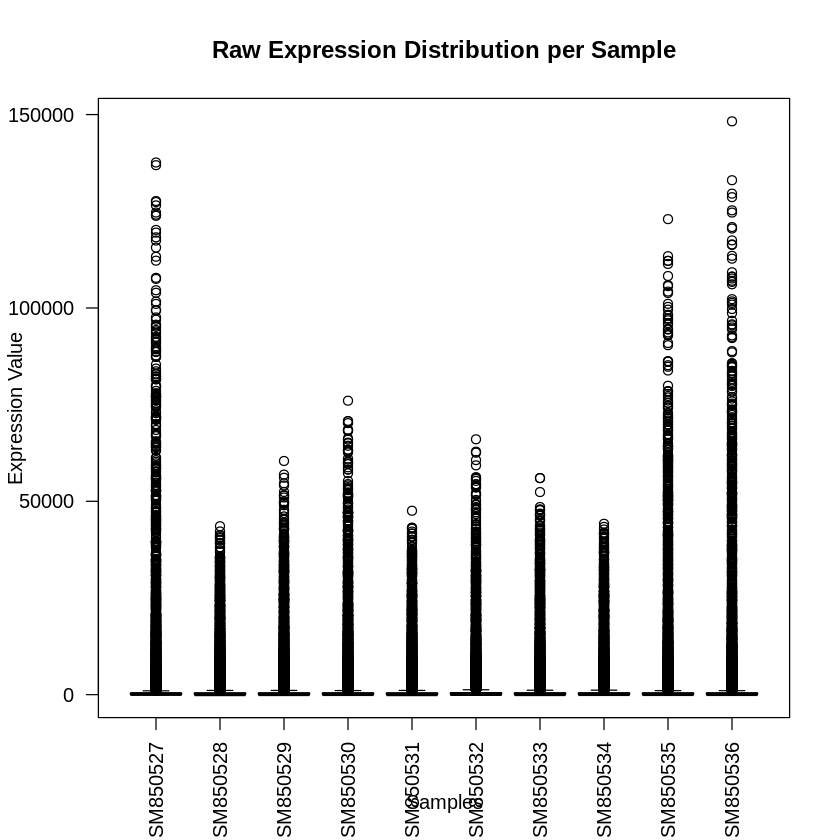

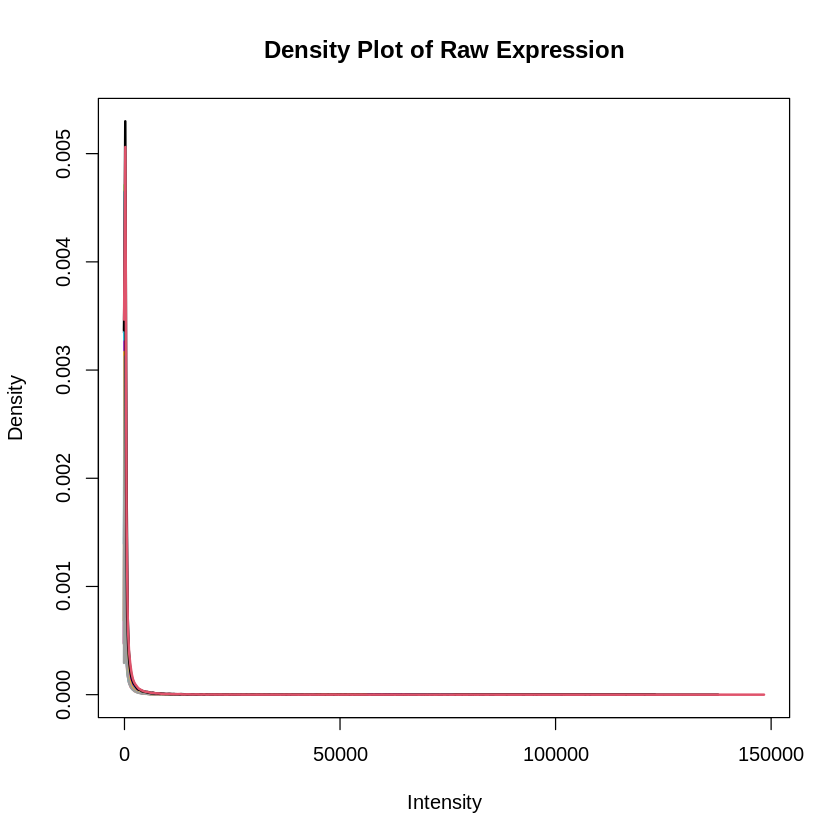

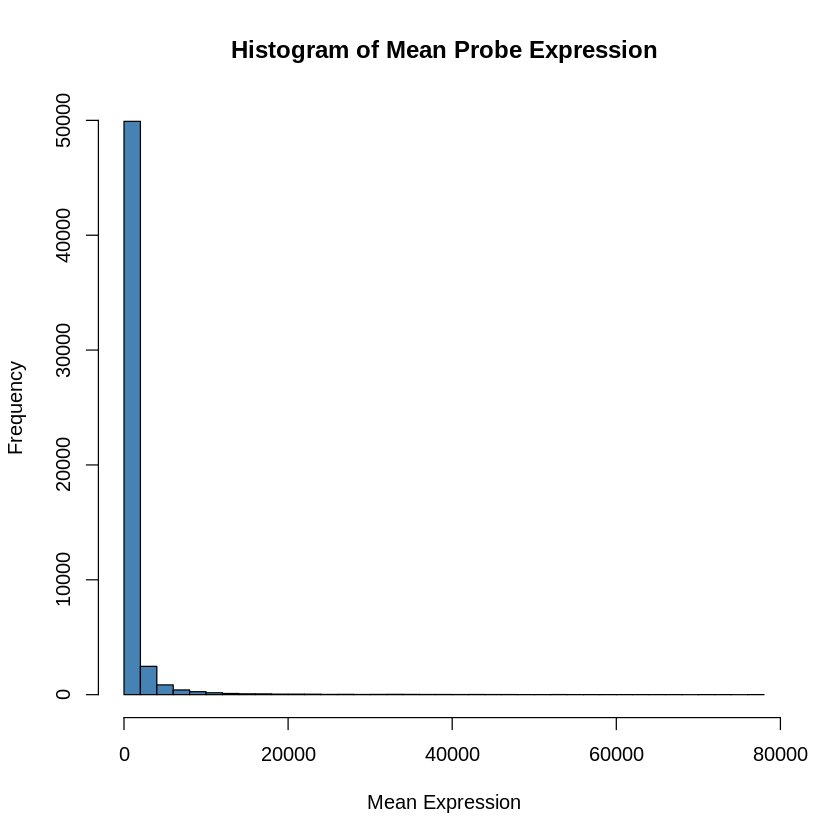

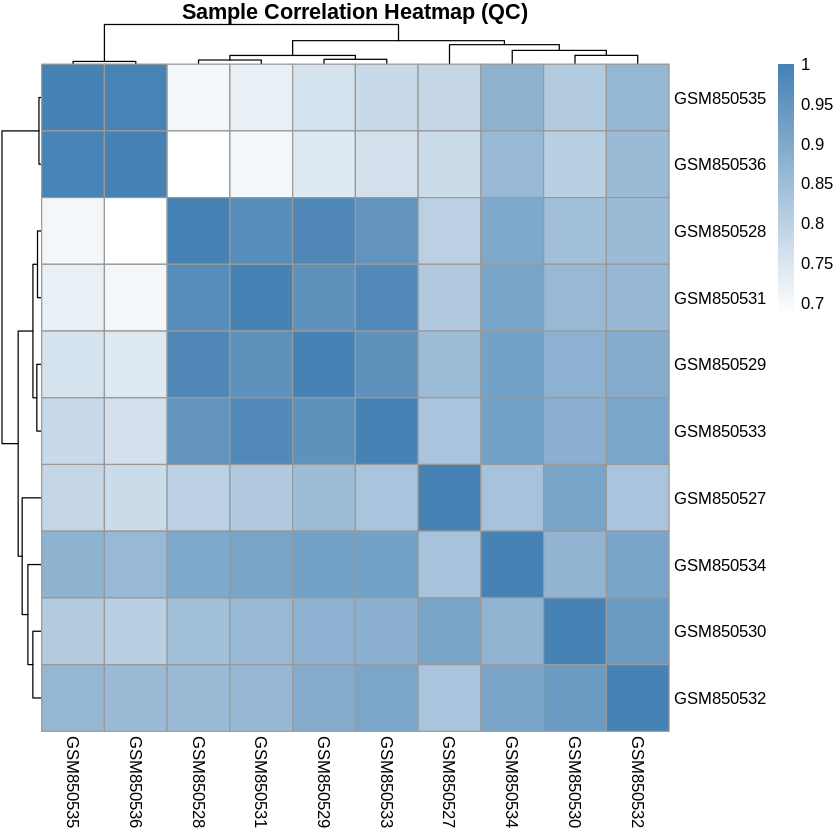

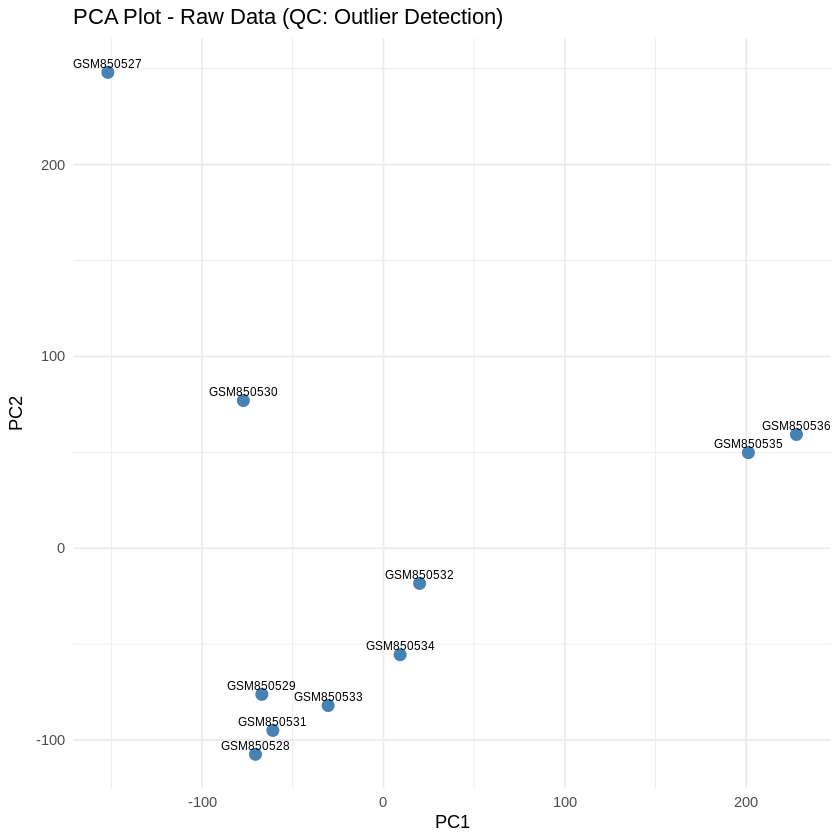

In [4]:
# --- 4a. Check for missing values ---
cat("Number of missing values:", sum(is.na(expr_matrix)), "\n")

# --- 4b. Boxplot of raw expression per sample ---
boxplot(expr_matrix,
        las = 2,
        col = "lightblue",
        main = "Raw Expression Distribution per Sample",
        ylab = "Expression Value",
        xlab = "Samples")

# --- 4c. Density plot of raw expression ---
plotDensities(expr_matrix,
              main = "Density Plot of Raw Expression",
              legend = FALSE)

# --- 4d. Histogram of mean expression values ---
hist(rowMeans(expr_matrix),
     breaks = 50,
     col = "steelblue",
     main = "Histogram of Mean Probe Expression",
     xlab = "Mean Expression")

# --- 4e. Sample correlation heatmap (QC) ---
cor_matrix <- cor(expr_matrix, method = "pearson")

pheatmap(cor_matrix,
         color = colorRampPalette(c("white", "steelblue"))(100),
         main = "Sample Correlation Heatmap (QC)",
         show_rownames = TRUE,
         show_colnames = TRUE,
         treeheight_row = 20,
         treeheight_col = 20)

# --- 4f. PCA plot on raw data to detect outlier samples ---
pca_raw <- prcomp(t(expr_matrix), scale. = TRUE)
pca_raw_df <- data.frame(PC1 = pca_raw$x[, 1],
                         PC2 = pca_raw$x[, 2],
                         Sample = colnames(expr_matrix))

ggplot(pca_raw_df, aes(x = PC1, y = PC2, label = Sample)) +
  geom_point(size = 3, color = "steelblue") +
  geom_text(vjust = -0.5, size = 2.5) +
  labs(title = "PCA Plot - Raw Data (QC: Outlier Detection)",
       x = "PC1", y = "PC2") +
  theme_minimal()

*Step 5: Data Cleaning*

In [9]:
# --- 5a. Remove probes with missing values ---
expr_clean <- na.omit(expr_matrix)
cat("Probes remaining after NA removal:", nrow(expr_clean), "\n")

# --- 5b. Remove low-expression probes (filter bottom 20% by median) ---
medians <- apply(expr_clean, 1, median)
threshold <- quantile(medians, 0.20)
expr_clean <- expr_clean[medians > threshold, ]
cat("Probes remaining after low-expression filter:", nrow(expr_clean), "\n")

# --- 5c. Assign group labels from phenotype data ---
group_labels <- ifelse(grepl("PCOS", pheno_data$title,
                             ignore.case = TRUE), "PCOS", "Healthy")
group_labels <- factor(group_labels, levels = c("Healthy", "PCOS"))
cat("Group labels:\n")
print(table(group_labels))

Probes remaining after NA removal: 54675 
Probes remaining after low-expression filter: 43740 
Group labels:
group_labels
Healthy    PCOS 
      3       7 


*Step 6: Normalization*

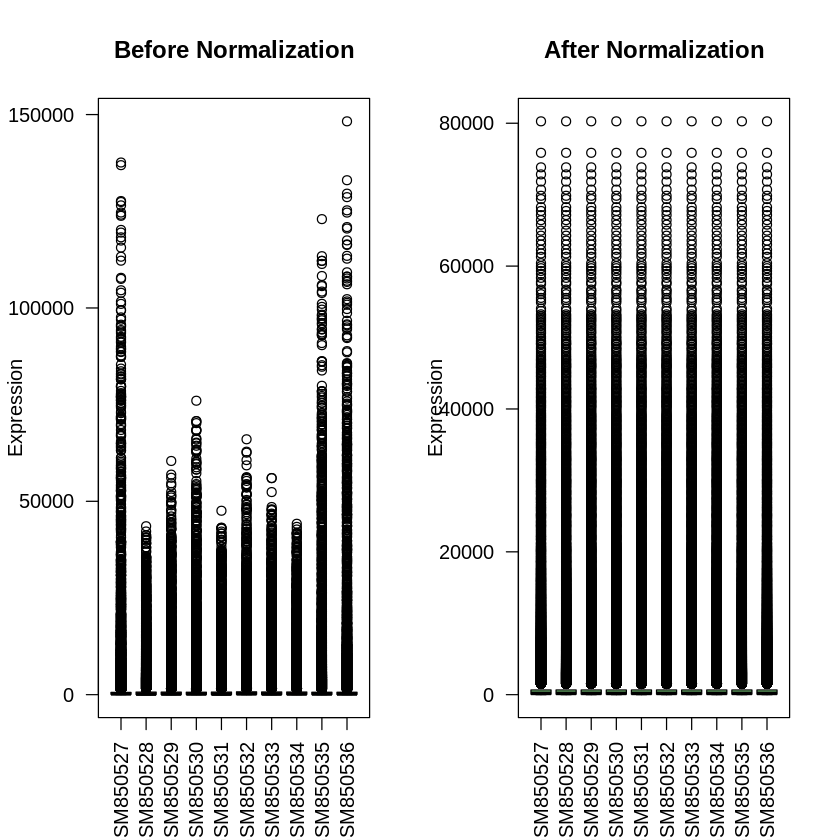

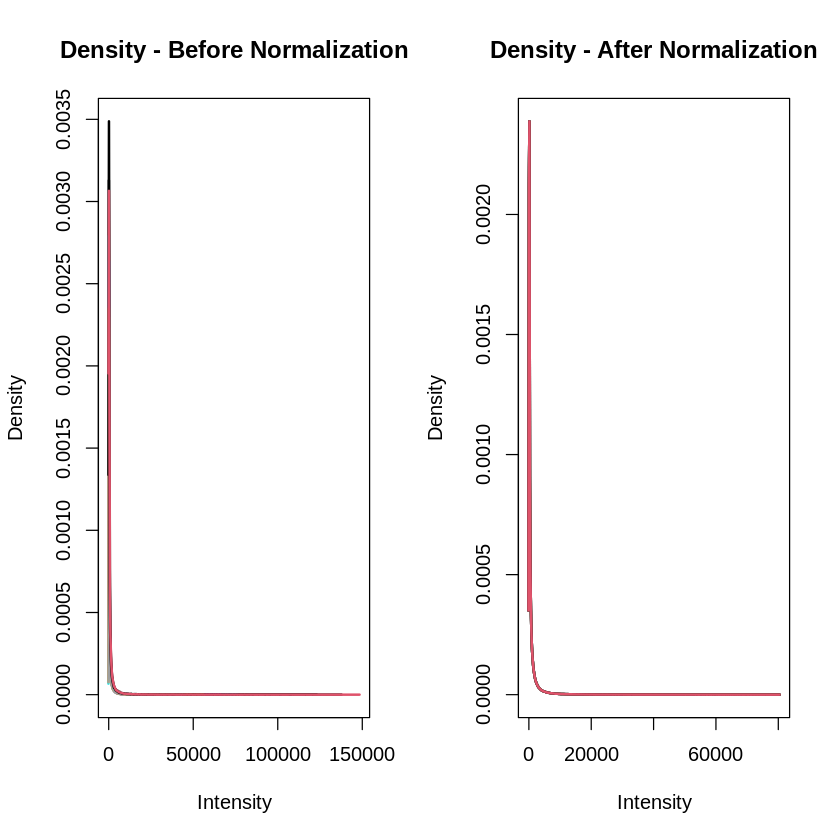

In [10]:
# Quantile normalization using limma
expr_norm <- normalizeBetweenArrays(expr_clean, method = "quantile")

# --- 6a. Boxplot before and after normalization ---
par(mfrow = c(1, 2))

boxplot(expr_clean,
        las = 2,
        col = "lightcoral",
        main = "Before Normalization",
        ylab = "Expression",
        xlab = "")

boxplot(expr_norm,
        las = 2,
        col = "lightgreen",
        main = "After Normalization",
        ylab = "Expression",
        xlab = "")

par(mfrow = c(1, 1))

# --- 6b. Density plot before and after normalization ---
par(mfrow = c(1, 2))

plotDensities(expr_clean,
              main = "Density - Before Normalization",
              legend = FALSE)

plotDensities(expr_norm,
              main = "Density - After Normalization",
              legend = FALSE)

par(mfrow = c(1, 1))

*Step 6c: (Gemini Assisted Cell) PCA on Normalized Data for Visualization Group Separation*

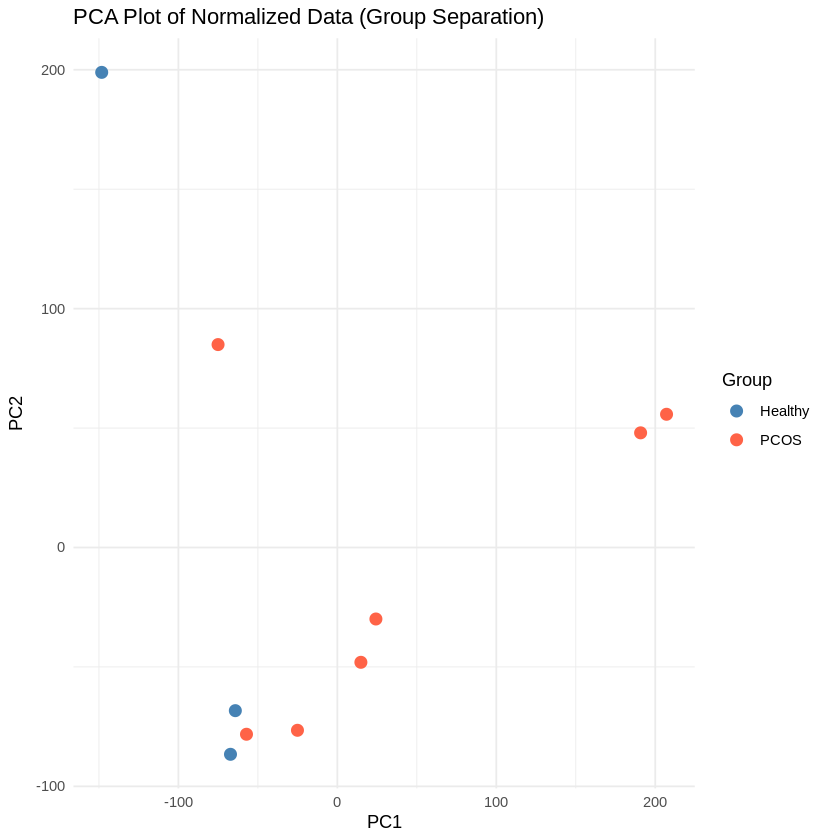

In [14]:
pca_norm_separation <- prcomp(t(expr_norm), scale. = TRUE)
pca_norm_separation_df <- data.frame(PC1   = pca_norm_separation$x[, 1],
                                     PC2   = pca_norm_separation$x[, 2],
                                     Group = group_labels)

ggplot(pca_norm_separation_df, aes(x = PC1, y = PC2, color = Group)) +
  geom_point(size = 3) +
  scale_color_manual(values = c("Healthy" = "steelblue",
                                "PCOS"    = "tomato")) +
  labs(title = "PCA Plot of Normalized Data (Group Separation)",
       x = "PC1", y = "PC2") +
  theme_minimal()

*Step 7: Differential Expression Analysis*

In [12]:
# --- 7a. Build design matrix ---
design <- model.matrix(~ 0 + group_labels)
colnames(design) <- levels(group_labels)

# --- 7b. Fit linear model ---
fit <- lmFit(expr_norm, design)

# --- 7c. Define contrast: PCOS vs Healthy ---
contrast_matrix <- makeContrasts(PCOS - Healthy, levels = design)
fit2 <- contrasts.fit(fit, contrast_matrix)

# --- 7d. Apply empirical Bayes moderation ---
fit2 <- eBayes(fit2)

# --- 7e. Extract all DEG results ---
deg_results <- topTable(fit2,
                        adjust.method = "fdr",
                        number = Inf,
                        sort.by = "P")

# Preview top results
head(deg_results)

# Count significant DEGs (FDR < 0.05, |log2FC| > 1)
sig_degs <- deg_results[deg_results$adj.P.Val < 0.05 &
                          abs(deg_results$logFC) > 1, ]
cat("Number of significant DEGs:", nrow(sig_degs), "\n")

# Label significance for visualizations
deg_results$Significance <- "Not Significant"
deg_results$Significance[deg_results$adj.P.Val < 0.05 &
                           deg_results$logFC > 1]  <- "Upregulated"
deg_results$Significance[deg_results$adj.P.Val < 0.05 &
                           deg_results$logFC < -1] <- "Downregulated"

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
206336_at,-963.7171,484.8688,-11.691617,1.128689e-06,0.02255074,-4.563373
225812_at,-635.4004,557.6871,-11.323231,1.473794e-06,0.02255074,-4.563516
218049_s_at,-553.0711,1685.0832,-11.257678,1.546690e-06,0.02255074,-4.563542
212554_at,-617.3890,447.6377,-10.150906,3.635460e-06,0.03975375,-4.564067
203799_at,2343.5635,4168.5637,9.544969,6.008701e-06,0.05256412,-4.564426
213894_at,-696.1723,521.0492,-9.207344,8.044300e-06,0.05524594,-4.564653


Number of significant DEGs: 4 


*Step 8: Visualization*

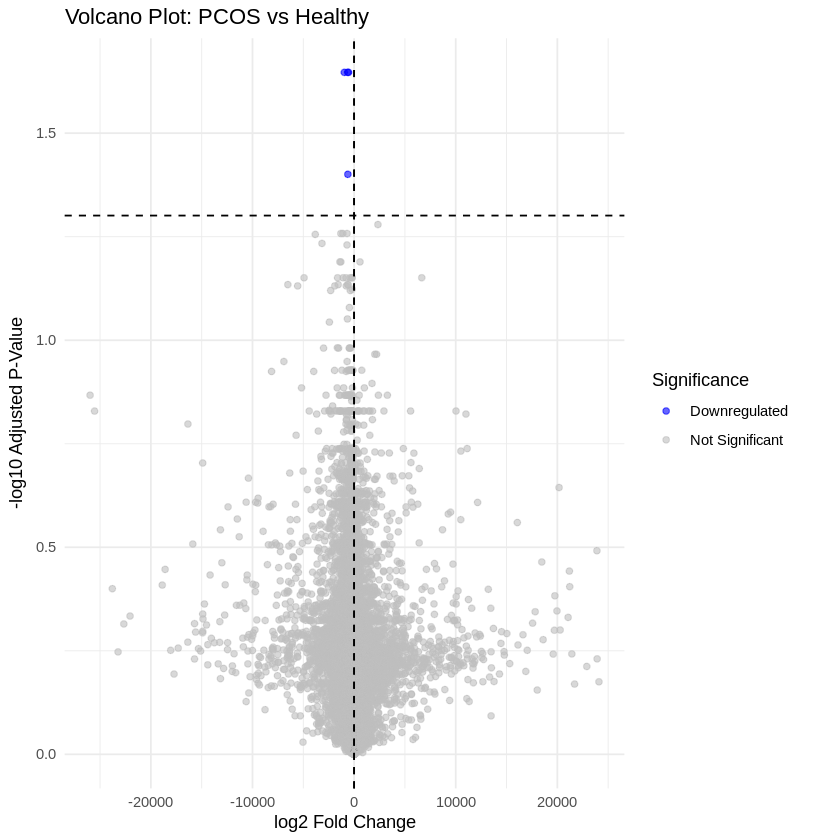

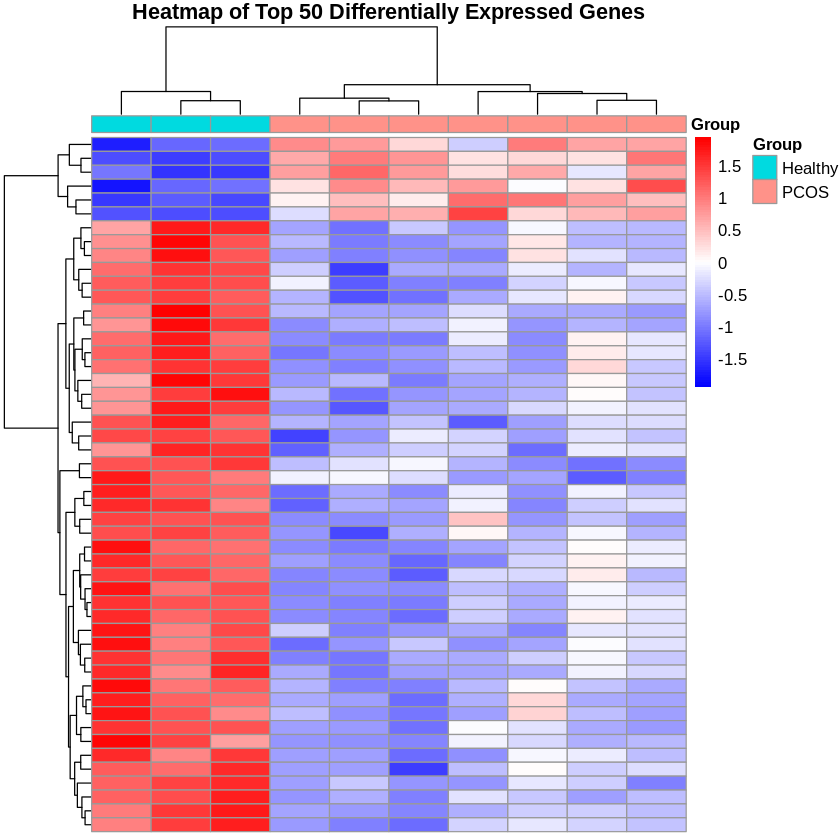

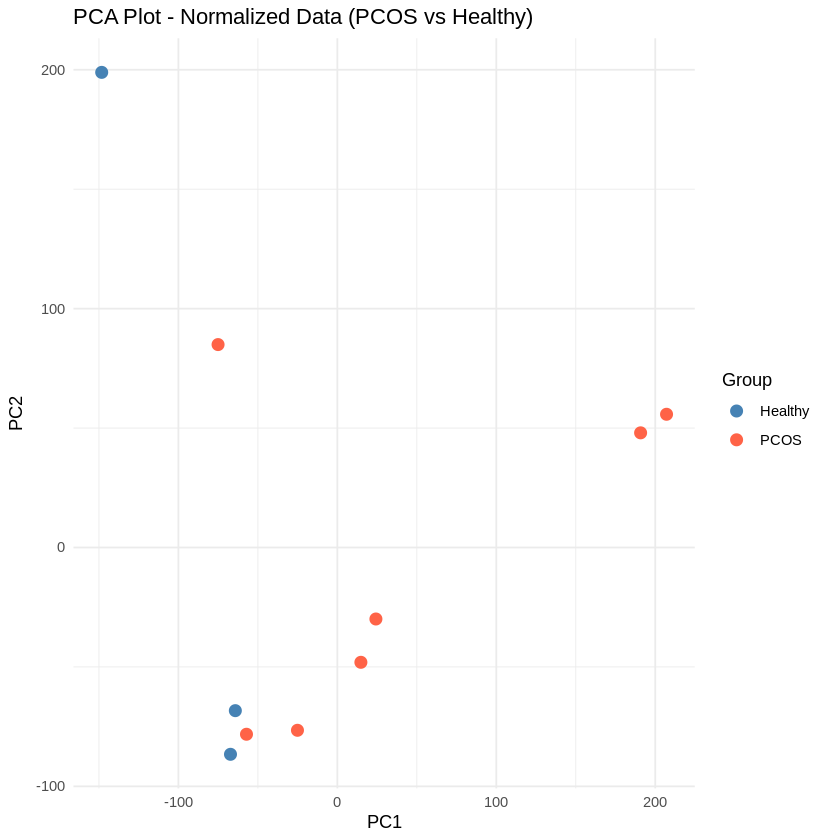

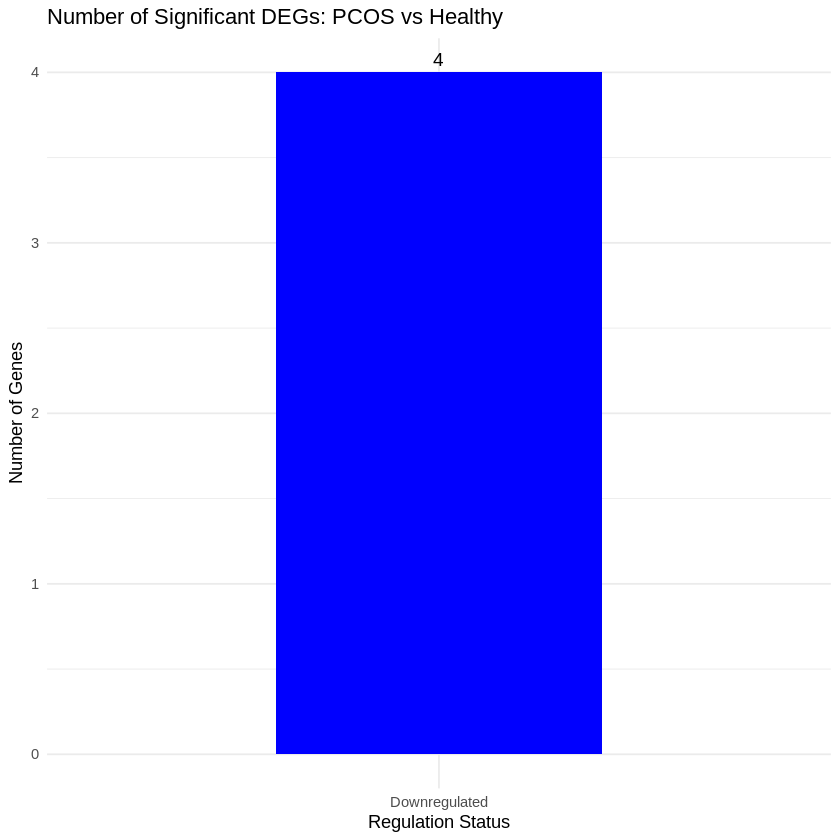

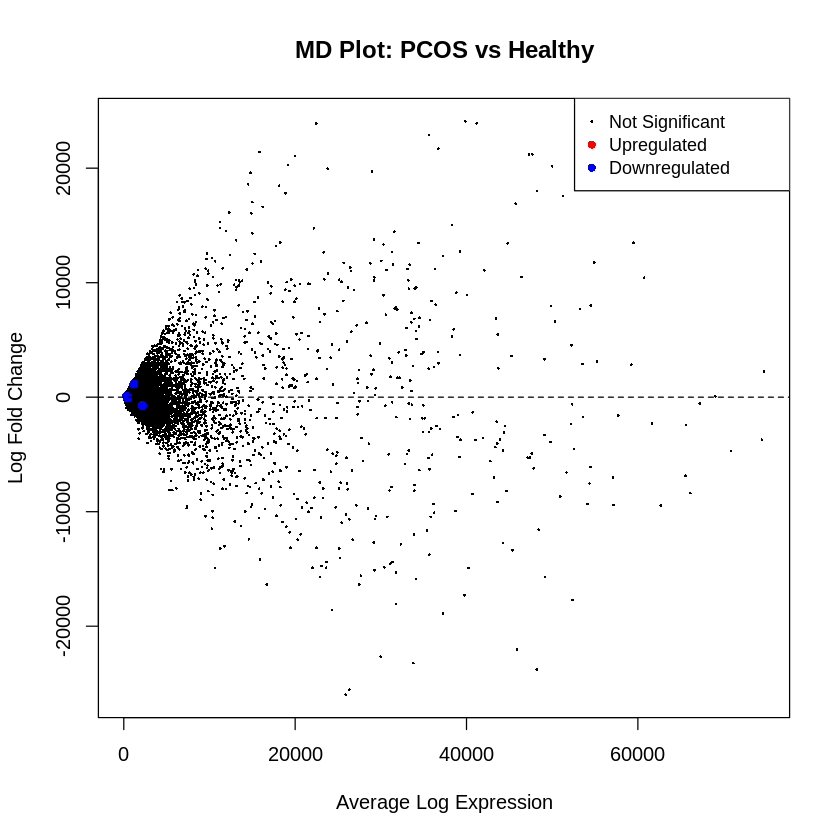

In [13]:
# --- 8a. Volcano Plot ---
ggplot(deg_results, aes(x = logFC,
                        y = -log10(adj.P.Val),
                        color = Significance)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("Upregulated"     = "red",
                                "Downregulated"   = "blue",
                                "Not Significant" = "grey")) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
  labs(title = "Volcano Plot: PCOS vs Healthy",
       x = "log2 Fold Change",
       y = "-log10 Adjusted P-Value") +
  theme_minimal()

# --- 8b. Heatmap of Top 50 DEGs ---
top50 <- rownames(deg_results)[1:50]
heatmap_data <- expr_norm[top50, ]

annotation_col <- data.frame(Group = group_labels)
rownames(annotation_col) <- colnames(expr_norm)

pheatmap(heatmap_data,
         annotation_col = annotation_col,
         scale = "row",
         show_rownames = FALSE,
         show_colnames = FALSE,
         color = colorRampPalette(c("blue", "white", "red"))(100),
         main = "Heatmap of Top 50 Differentially Expressed Genes")

# --- 8c. PCA Plot After Normalization (colored by group) ---
pca_norm <- prcomp(t(expr_norm), scale. = TRUE)
pca_norm_df <- data.frame(PC1    = pca_norm$x[, 1],
                           PC2    = pca_norm$x[, 2],
                           Group  = group_labels)

ggplot(pca_norm_df, aes(x = PC1, y = PC2, color = Group)) +
  geom_point(size = 3) +
  scale_color_manual(values = c("Healthy" = "steelblue",
                                "PCOS"    = "tomato")) +
  labs(title = "PCA Plot - Normalized Data (PCOS vs Healthy)",
       x = "PC1", y = "PC2") +
  theme_minimal()

# --- 8d. Bar Chart of DEG Counts (Up vs Downregulated) ---
deg_counts <- as.data.frame(table(deg_results$Significance))
colnames(deg_counts) <- c("Regulation", "Count")
deg_counts <- deg_counts[deg_counts$Regulation != "Not Significant", ]

ggplot(deg_counts, aes(x = Regulation, y = Count, fill = Regulation)) +
  geom_bar(stat = "identity", width = 0.5) +
  scale_fill_manual(values = c("Upregulated"   = "red",
                               "Downregulated" = "blue")) +
  geom_text(aes(label = Count), vjust = -0.5, size = 4) +
  labs(title = "Number of Significant DEGs: PCOS vs Healthy",
       x = "Regulation Status",
       y = "Number of Genes") +
  theme_minimal() +
  theme(legend.position = "none")

# --- 8e. MD Plot (Mean-Difference Plot) ---
plotMD(fit2,
       column = 1,
       status = deg_results$Significance,
       values = c("Upregulated", "Downregulated"),
       col    = c("red", "blue"),
       main   = "MD Plot: PCOS vs Healthy",
       xlab   = "Average Log Expression",
       ylab   = "Log Fold Change")
abline(h = 0, col = "black", lty = 2)